In [2]:
"""
Minimal working example for the pygimli workshop
"""
import numpy as np
import pygimli as pg
from pygimli.physics import ert

In [3]:
# %% Part 1/5: Data import
data = pg.DataContainerERT()
data.load('data.dat')
# pg.show(data)

1

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x7f2368f2fa10>)

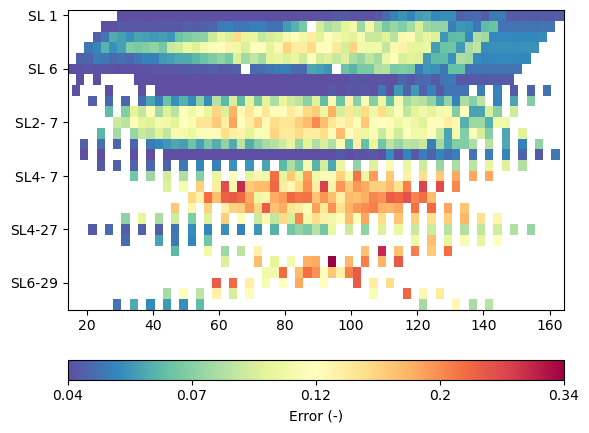

In [4]:
# %% Part 2/5: Estimate error
data['err'] = ert.estimateError(
    data,
    relativeError=0.04,
    absoluteUError=5e-5)

data.show('err')

16/02/25 - 15:39:47 - pyGIMLi - INFO - Found 2 regions.
16/02/25 - 15:39:47 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/02/25 - 15:39:47 - pyGIMLi - INFO - Found 2 regions.
16/02/25 - 15:39:47 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/02/25 - 15:39:47 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/02/25 - 15:39:47 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/02/25 - 15:39:47 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 9856 Cells: 19204 Boundaries: 14656


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

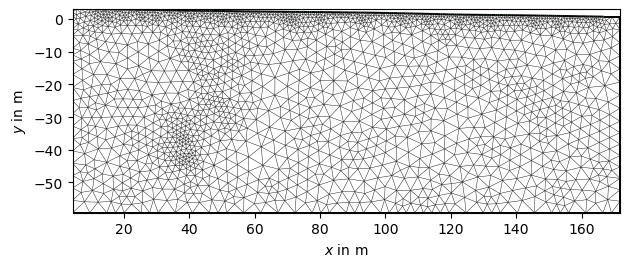

In [5]:
# %% Part 3/5: ERT Manager
mgr = ert.ERTManager(data)

mesh_param = {'paraMaxCellSize': 10,
              'quality': 34.4,
              'paraDepth': 60,
              'paraDX': 0.25
              }

mesh = mgr.createMesh(**mesh_param)
mgr.setMesh(mesh)
pg.show(mgr.paraDomain)
# pg.show(mesh)

In [6]:
# %% Part 4/5: Inversion
mgr.inv.setRegularization(2, zWeight=0.1)
inv_param = {'lam': 20,
             'startmodel': np.median(data["rhoa"])}
mgr.invert(**inv_param)


16/02/25 - 15:39:58 - pyGIMLi - INFO - Use median(data values)=3.06844394897819


3589 [3406.6860567381054,...,6.615975685852369]

In [8]:
# %% Part 5/5: Save model, response and coverage
results = {
    'model': mgr.model.array(),
    'coverage': mgr.coverage(),
    'response': mgr.inv.response.array(),
    'chi2': mgr.inv.inv.getChi2(),
    'rrms': mgr.inv.relrms(),
    'error': data['err']
    }
np.savez('ert_example1.npz', **results)
mgr.paraDomain.save('mesh_example1.bms')

1